<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Session 3 · Hierarchical Clustering & Dendrogram</h4>
<h1 align="center">Hierarchical Clustering — Country Development Indicators</h1>
<p align="center"><i>Exploratory data analysis of the country socio-economic indicators</i></p>

---

## 1. The Data Drives the Model, Not the Other Way Around

It is tempting, especially with clustering, to treat EDA as a formality and jump straight to
calling `AgglomerativeClustering(...)`. Resist that urge. For **unsupervised learning
specifically**, EDA is not optional — it is the *only* safety net you have.

> **Why this matters more here than in supervised learning.** In a supervised model, if you
> misunderstand a feature, the model's accuracy against the true labels will eventually
> expose the mistake. In clustering, **there are no labels**. If you don't know that `income`
> is measured in raw dollars (hundreds to tens of thousands) while `total_fer` is a small
> single-digit number (children per woman), you will not understand why an unscaled Euclidean
> distance between two countries is almost entirely determined by `income` and `gdpp` — and
> you will misread whatever clusters come out, with nothing to catch the mistake.

EDA is how we build the mental model of the data that lets us:

- Recognize when a variable's scale will dominate a distance calculation (motivating
  `StandardScaler` in `02_data_processing`).
- Distinguish **real, informative extreme values** (e.g. a tiny, extremely wealthy nation)
  from data errors.
- Anticipate roughly how many natural groups might exist, so the dendrogram and cluster
  count we choose later make real-world sense.

Let's load the cleaned data and look carefully.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("data/country_data_clean.csv")
print(df.shape)
df.head()

(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


Notice immediately in the table above: `income` ranges from roughly 600 to over
100,000, `gdpp` ranges from roughly 200 to over 100,000, while `total_fer` ranges from about
1 to 7, and `health` (% of GDP) ranges from about 1 to 18. This confirms the warning above —
these columns live on completely different numeric scales, even though every one of them is
equally important conceptually for describing a country's development level.

---

## 2. Univariate Distributions

### 2.1 Histograms of the four headline indicators

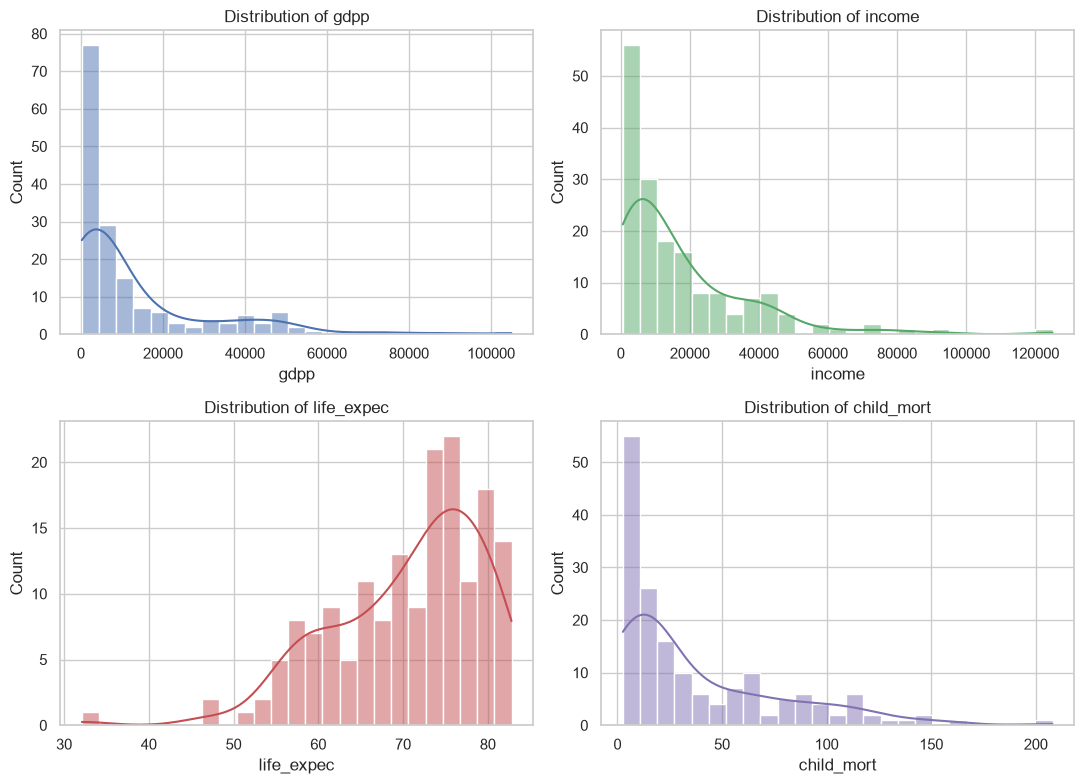

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
cols = ["gdpp", "income", "life_expec", "child_mort"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for ax, col, color in zip(axes.flat, cols, colors):
    sns.histplot(df[col], bins=25, kde=True, ax=ax, color=color)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

**Reading these distributions:**

- `gdpp` and `income` are both strongly **right-skewed**: most countries cluster at lower
  values, with a long tail of wealthy nations. This is typical of economic data and is a
  strong hint that a handful of very wealthy outlier countries exist (we'll confirm this with
  a boxplot shortly).
- `life_expec` is left-skewed (a concentration of countries with high life expectancy, and a
  tail of lower values) — the mirror image of what we'd expect for a "development" measure.
- `child_mort` is right-skewed with a long tail of very high values — these are the countries
  most in need of urgent aid, and precisely the extreme values the NGO cares about.

### 2.2 Pairwise relationships

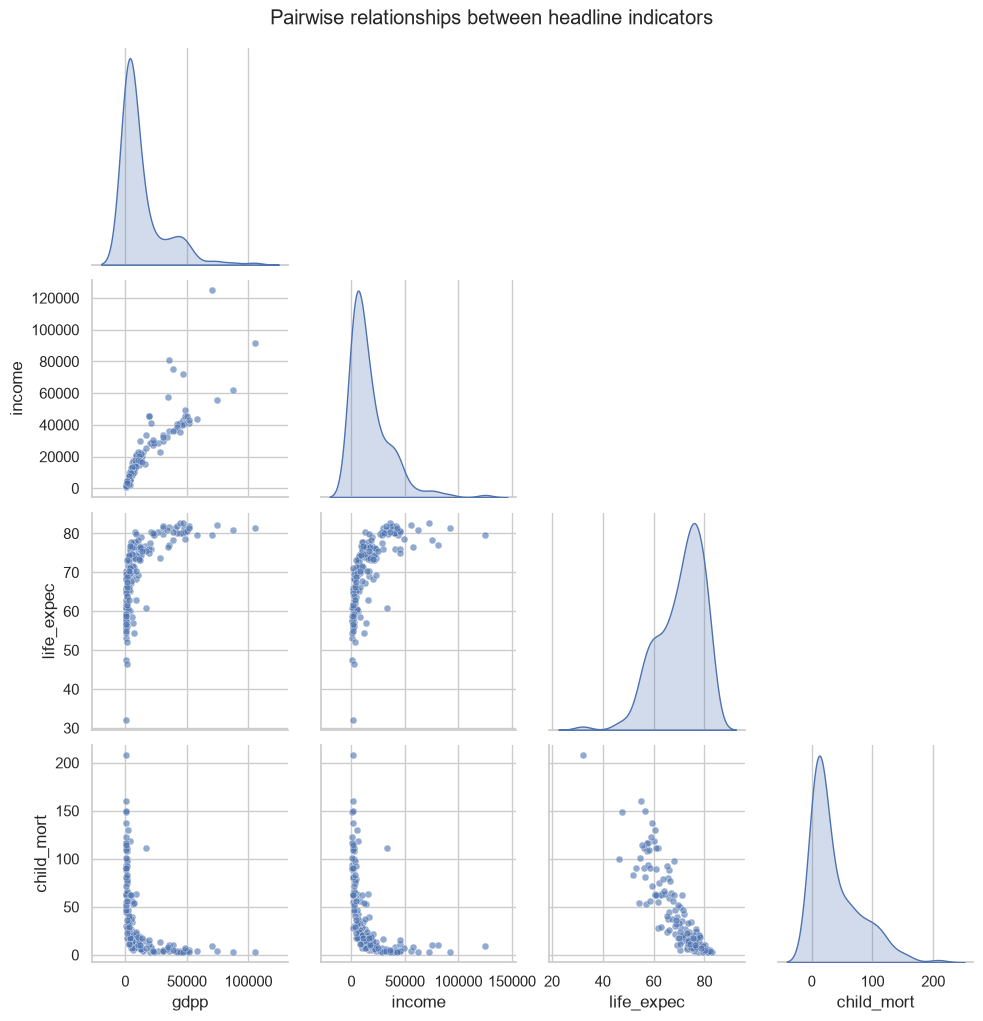

In [4]:
pairplot_cols = ["gdpp", "income", "life_expec", "child_mort"]
g = sns.pairplot(df[pairplot_cols], diag_kind="kde", corner=True,
                  plot_kws={"alpha": 0.6, "s": 25})
g.fig.suptitle("Pairwise relationships between headline indicators", y=1.02)
plt.show()

The pairplot reveals the relationships that will drive the clusters we eventually
find:

- `gdpp` and `income` are **strongly positively correlated** — unsurprising, since national
  output and personal income move together.
- `child_mort` is **strongly negatively correlated** with both `gdpp` and `life_expec`:
  poorer countries with lower life expectancy tend to have much higher child mortality. This
  is the core "development axis" the NGO cares about.
- The point clouds are not uniform — there are visible denser regions (e.g., a cluster of
  low-`gdpp`, high-`child_mort` countries, and a separate cluster of high-`gdpp`,
  low-`child_mort` countries), foreshadowing that hierarchical clustering should find at
  least two or three meaningfully different groups.

### 2.3 Correlation heatmap across all 9 indicators

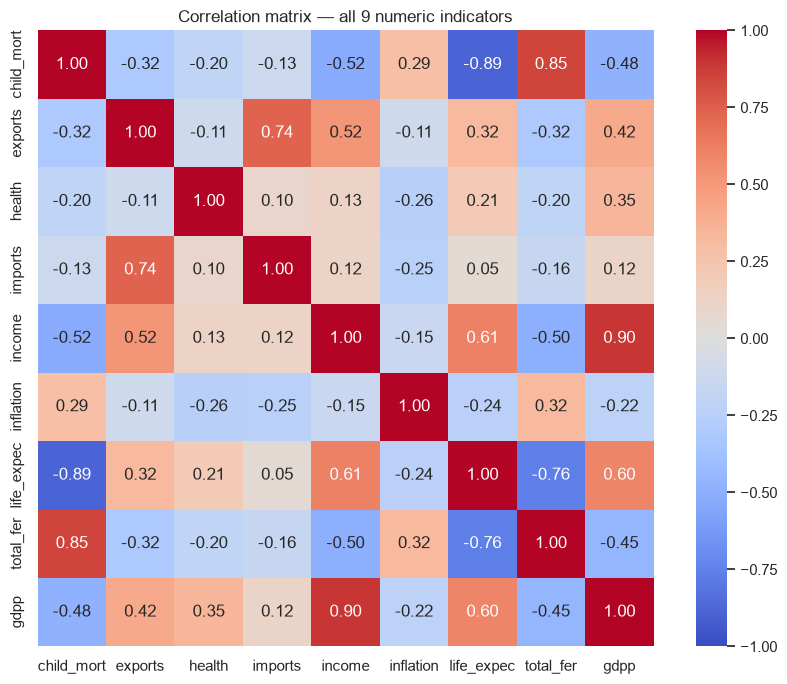

In [5]:
numeric_cols = ["child_mort", "exports", "health", "imports", "income",
                "inflation", "life_expec", "total_fer", "gdpp"]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation matrix — all 9 numeric indicators")
plt.tight_layout()
plt.show()

**Interpreting the heatmap:**

- `gdpp` and `income` correlate at roughly **0.9+** — they carry a lot of overlapping
  information about the same underlying "wealth" concept.
- `child_mort` and `total_fer` are strongly **positively** correlated with each other, and
  both are strongly **negatively** correlated with `life_expec`, `income`, and `gdpp`. This
  cluster of correlated variables essentially describes one dominant "development" axis.
- `exports`, `imports`, `health`, and `inflation` are comparatively weakly correlated with
  everything else — they add complementary information (e.g. two countries with similar
  `gdpp` might differ a lot in trade openness or inflation).

> **Blockquote — why this matters for clustering.** Highly correlated features (like `gdpp`
> and `income`) effectively get **double-counted** by a Euclidean distance metric, since
> moving along one tends to move along the other too. This isn't necessarily wrong — if two
> variables really do represent the same underlying "wealth" concept, letting that concept
> dominate the clustering is often exactly what we want — but it's important to know this is
> happening rather than being surprised by it later.

---

## 3. Outliers: Errors or Real Extremes?

### 3.1 Boxplot of `gdpp` and `income`

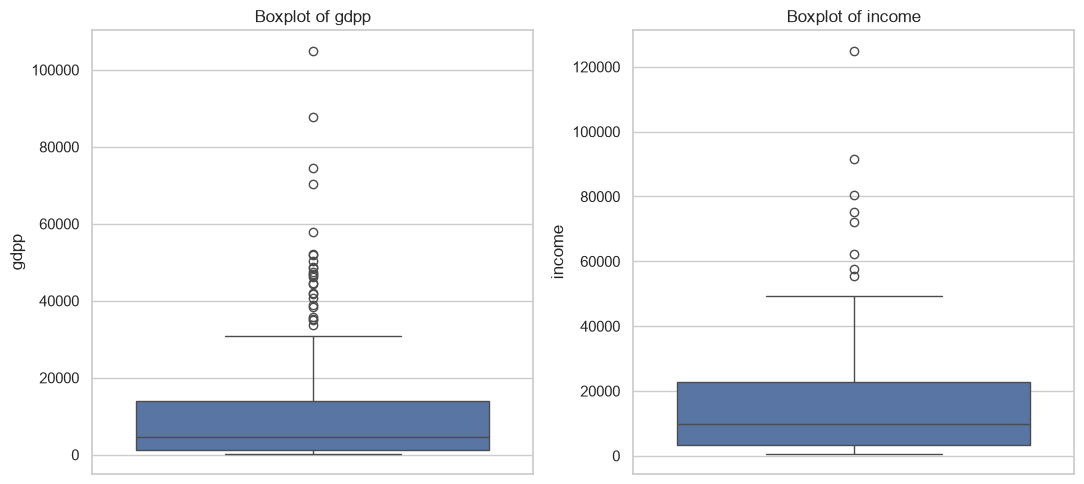

,country,gdpp,income,life_expec,child_mort
91,Luxembourg,105000,91700,81.3,2.8
114,Norway,87800,62300,81.0,3.2
145,Switzerland,74600,55500,82.2,4.5
123,Qatar,70300,125000,79.5,9.0
44,Denmark,58000,44000,79.5,4.1
144,Sweden,52100,42900,81.5,3.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, col in zip(axes, ["gdpp", "income"]):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

top_gdpp = df.nlargest(6, "gdpp")[["country", "gdpp", "income", "life_expec", "child_mort"]]
top_gdpp

The boxplots flag several countries as statistical outliers on the high end of `gdpp`
and `income` — small, extremely wealthy nations (oil-rich Gulf states, financial/trading
hubs, and similar). It would be a mistake to treat these as data errors and drop them.

> **Callout — keep these extremes.** These are **real, informative extreme values**, not
> measurement errors:
>
> - They correspond to genuine, verifiable economic profiles (small population, very high
>   GDP per capita from oil, finance, or trade).
> - Removing them would artificially compress the range of "wealthy" countries and could hide
>   a genuinely distinct cluster.
> - For the NGO's purposes, this is actually a *useful* signal: hierarchical clustering will
>   likely group these into their own small, high-wealth cluster, clearly distinguishing
>   "donor / high-income" nations from the rest — which is exactly the kind of structure the
>   NGO wants to discover, not something to be scaled away by outlier removal.

We will, however, need to **scale** the data before clustering (Section 2 in
`02_data_processing`) so that these large-magnitude outliers don't single-handedly dominate
every distance calculation — that is a scaling decision, not a data-removal decision.

---

## 4. Geographic View: The Signature Visual for This Topic

### 4.1 Choropleth map of GDP per capita

In [7]:
fig = px.choropleth(
    df,
    locations="country",
    locationmode="country names",
    color="gdpp",
    hover_name="country",
    hover_data=["income", "life_expec", "child_mort"],
    color_continuous_scale="Viridis",
    title="GDP per Capita by Country",
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_35984\3859215242.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


The choropleth immediately shows the **geographic clustering of development** that
underlies this whole exercise: a visible concentration of low-`gdpp` countries across
Sub-Saharan Africa and parts of South Asia, contrasted with high-`gdpp` clusters in North
America, Western Europe, and the oil-rich Gulf states. This is a strong visual preview of
what hierarchical clustering should recover numerically — geography is not one of our
clustering features, but it correlates heavily with the socio-economic groupings we expect
to find.

### 4.2 3D relationship between income, life expectancy, and GDP per capita

In [8]:
fig = px.scatter_3d(
    df,
    x="income",
    y="life_expec",
    z="gdpp",
    color="child_mort",
    hover_name="country",
    color_continuous_scale="Inferno_r",
    title="Income vs. Life Expectancy vs. GDP per Capita (colored by child mortality)",
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.show()

Rotating this 3D view (interactively, in a live notebook) makes the same "development
axis" visible from Section 2.2: countries with low `income`, low `life_expec`, and low `gdpp`
also tend to have the highest `child_mort` (darker points), while high-`income`,
high-`life_expec`, high-`gdpp` countries cluster together with low `child_mort`. There is
also a visible small group of countries with unusually high `income`/`gdpp` relative to their
`life_expec` — worth remembering when we profile clusters later.

---

## 5. Summary Going Into Preprocessing

- The dataset's numeric columns live on very different scales (`income`/`gdpp` in the
  thousands vs. `total_fer`/`health` in single digits) — **scaling is mandatory** before any
  distance-based clustering.
- There is a strong, dominant "development axis" running through `child_mort`, `life_expec`,
  `income`, and `gdpp`, all correlated with each other. Hierarchical clustering will very
  likely organize countries primarily along this axis.
- A handful of extremely wealthy, small economies are real, informative outliers — we keep
  them and expect them to form their own small cluster.
- The choropleth and 3D scatter both suggest that a small number of clusters (likely 2-4,
  as we'll formally test) will represent the data well.

Next, `02_data_processing.ipynb` will scale the features, add a PCA projection for
visualization, and set up a lightweight subsampling scheme so we can sanity-check cluster
stability later.